# Paper figures

Generates every figure for the writeup of *Cross-modal information flow in LLaVA-v1.5-7b*.

All numbers come from committed `*.summary.json` files. No experiment is run, no raw
(gitignored) result file is read, and nothing under `sae_experiments/` is touched.
Figures are written to `output/paper_figures/` at 300 dpi.

Run the **Setup** cell once; after that every figure cell runs independently.

## Source-file notes

Two things about the ablation paths are worth stating up front, because the filenames are
not consistent across layers:

- **Layer 11** has two runs. `results/ablation_results.summary.json` is the n=256 headline run
  and the one used here. `results/ablation_v2_results.summary.json` is an n=50 run — not used.
- **Layer 14** was run on 2026-08-06, after `LLM_TECHNICAL_SUMMARY.md` was last written; that
  document still lists it as "not run". Its summary was distilled with
  `tools/distill_results.py` and lives at `results/ablation_v2_results.summary.json`.
- **Layer 10** also has two runs, and this is the one that trips people up. The technical
  summary's prose mentions the nested path `results/ablation_v2/ablation_v2_results.json`,
  but the numbers it actually reports (0.15141, z=66.5, 81.2% positive) come from the *flat*
  `results/ablation_results.summary.json` — which is what `LLM_TECHNICAL_SUMMARY.json`
  records under `layers.10.ablation_v2.source`. The nested file is a different run of the
  same config (0.15097, z=56.2, 82.0% positive). This notebook uses the flat file, and the
  figure-2 cell prints both so the difference stays visible.

## One number here disagrees with the technical summary

`LLM_TECHNICAL_SUMMARY.md` states there is **zero overlap** between the v1 and v2 top-200
feature sets. The committed catalogs give an overlap of **2** (features 18443 and 20629).
Figure 4 prints the computed value, not the summary's. See that cell for the full caveat —
the two SAEs are different dictionaries, so the overlap is close to meaningless either way,
but it is not zero.

## Setup

Paths, palette and matplotlib defaults. Every figure cell below depends only on this cell.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path("..").resolve()
SAE = REPO / "output/sae_experiments"
FIGDIR = REPO / "output/paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-2 plus chart ink, from the validated reference palette.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
CRIT = "#d03b3b"
INK = "#0b0b0b"
SECOND = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#ffffff"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.labelcolor": INK,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
})


def tidy(ax):
    """Recessive grid and axes: drop the top/right spines, put the grid behind the marks."""
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


print("repo :", REPO)
print("figs :", FIGDIR)

repo : /home/ron/Documents/Github/cross-modal-information-flow-in-MLLM
figs : /home/ron/Documents/Github/cross-modal-information-flow-in-MLLM/output/paper_figures


---

### Figure 1 — Attention-knockout landscape

Blocking the `Image->Question` attention flow one layer at a time reveals three regions: a
strong early site at layer 0, a mid-network cluster at layers 10-14, and late-layer
inhibition where blocking the flow slightly *improves* the margin. The `Image->Last` flow is
an order of magnitude weaker everywhere. Caveat: the negative drops at layers 13, 26 and 29
are real signal, not bugs, and all 64 points are n=7084 with p < 1e-10.

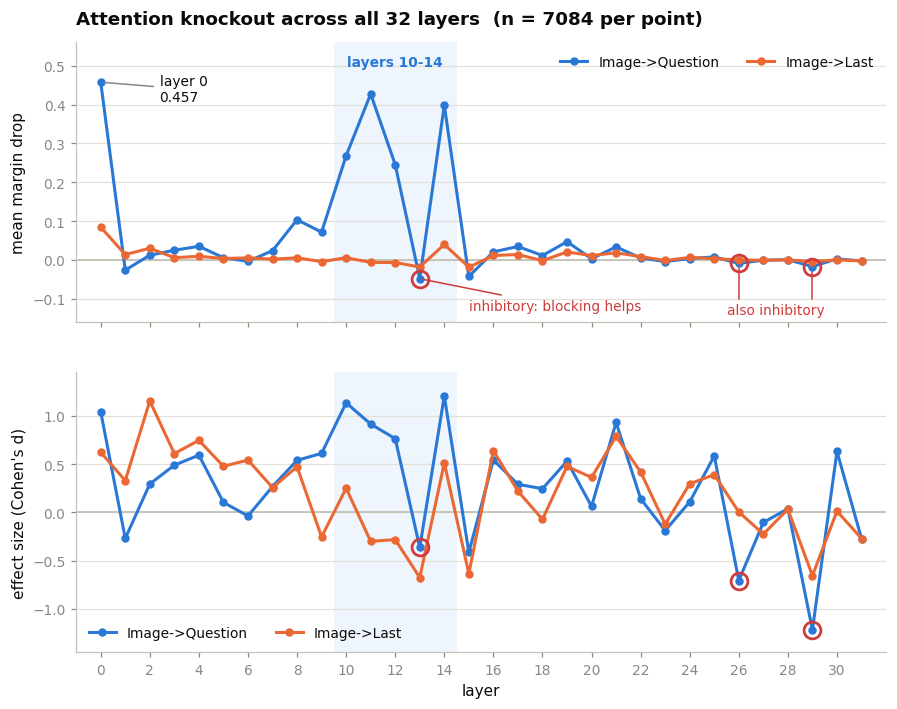

Image->Question, n = 7084 per layer
  layer  0  drop +0.4575  d +1.042  p 0
  layer 10  drop +0.2683  d +1.135  p 0
  layer 11  drop +0.4273  d +0.915  p 0
  layer 12  drop +0.2452  d +0.764  p 0
  layer 13  drop -0.0483  d -0.364  p 4.83e-194
  layer 14  drop +0.3983  d +1.205  p 0
  layer 26  drop -0.0091  d -0.707  p 0
  layer 29  drop -0.0170  d -1.218  p 0

Image->Question layers with a negative drop: [1, 6, 13, 15, 23, 26, 27, 29, 31]
Image->Last  max drop 0.0844 (layer 0)  vs  Image->Question max 0.4575 (layer 0)


In [2]:
ko = json.load(open(SAE / "exp_default/knockout/knockout_summary.json"))

question = sorted([r for r in ko if r["flow"] == "Image->Question"], key=lambda r: r["layer"])
last = sorted([r for r in ko if r["flow"] == "Image->Last"], key=lambda r: r["layer"])

layers = [r["layer"] for r in question]
q_drop = [r["mean_margin_drop"] for r in question]
q_d = [r["effect_size"] for r in question]
l_drop = [r["mean_margin_drop"] for r in last]
l_d = [r["effect_size"] for r in last]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.2), sharex=True,
                               gridspec_kw={"hspace": 0.18})

for ax in (ax1, ax2):
    ax.axvspan(9.5, 14.5, color=BLUE, alpha=0.07, lw=0, zorder=0)
    ax.axhline(0, color=BASELINE, lw=1.2, zorder=1)
    tidy(ax)

ax1.plot(layers, q_drop, color=BLUE, lw=2, marker="o", ms=4.5, label="Image->Question", zorder=3)
ax1.plot(layers, l_drop, color=ORANGE, lw=2, marker="o", ms=4.5, label="Image->Last", zorder=3)
ax2.plot(layers, q_d, color=BLUE, lw=2, marker="o", ms=4.5, label="Image->Question", zorder=3)
ax2.plot(layers, l_d, color=ORANGE, lw=2, marker="o", ms=4.5, label="Image->Last", zorder=3)

# The three negative Image->Question drops called out in the writeup.
for L in (13, 26, 29):
    ax1.plot(L, q_drop[L], marker="o", ms=11, mfc="none", mec=CRIT, mew=1.8, zorder=4)
    ax2.plot(L, q_d[L], marker="o", ms=11, mfc="none", mec=CRIT, mew=1.8, zorder=4)

ax1.annotate("layer 0\n0.457", xy=(0, q_drop[0]), xytext=(2.4, 0.44),
             color=INK, fontsize=9, va="center",
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax1.text(12, 0.50, "layers 10-14", color=BLUE, fontsize=9, ha="center", fontweight="bold")
ax1.annotate("inhibitory: blocking helps", xy=(13, q_drop[13]), xytext=(18.5, -0.128),
             color=CRIT, fontsize=9, ha="center",
             arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))
for L in (26, 29):
    ax1.plot([L, L], [q_drop[L] - 0.012, -0.10], color=CRIT, lw=1, zorder=2)
ax1.text(27.5, -0.128, "also inhibitory", color=CRIT, fontsize=9, ha="center", va="center")

ax1.set_ylabel("mean margin drop")
ax1.set_ylim(-0.16, 0.56)
ax1.set_title("Attention knockout across all 32 layers  (n = 7084 per point)", loc="left", pad=12)
ax1.legend(loc="upper right", ncol=2)

ax2.set_ylabel("effect size (Cohen's d)")
ax2.set_xlabel("layer")
ax2.set_ylim(-1.45, 1.45)
ax2.set_xticks(range(0, 32, 2))
ax2.set_xlim(-1, 32)
ax2.legend(loc="lower left", ncol=2)

fig.savefig(FIGDIR / "fig1_knockout_landscape.png")
plt.show()

print("Image->Question, n =", question[0]["samples"], "per layer")
for L in (0, 10, 11, 12, 13, 14, 26, 29):
    r = question[L]
    print("  layer %2d  drop %+.4f  d %+.3f  p %.3g" % (L, r["mean_margin_drop"], r["effect_size"], r["p_value"]))
print()
print("Image->Question layers with a negative drop:",
      [r["layer"] for r in question if r["mean_margin_drop"] < 0])
print("Image->Last  max drop %.4f (layer %d)  vs  Image->Question max %.4f (layer %d)"
      % (max(l_drop), int(np.argmax(l_drop)), max(q_drop), int(np.argmax(q_drop))))

---

### Figure 2 — SAE feature ablation against random controls

**Caveat that governs this whole figure: the controls are uniform draws, not matched.** The
configs request matching on `correct_mean`, a key absent from every v2 stats file, so the
sampler silently fell back to uniform — at layer 11 the controls have median activation 6.1e-08
against the binding set's 0.117. The separation shown here is therefore against near-dead
features and the z-scores are inflated by an unknown amount; the margin drops and the per-sample
positive fractions are unaffected. Re-runs with matched controls are pending.

Ablating the top-200 causally-identified features moves the margin far outside the spread of
15 random control sets at every layer tested: **layer 14 gives the largest drop**
(0.2433, with 90.2% of samples positive) while **layer 11 gives the largest separation from
its controls** (z = 81.6 vs 70.0, because layer 14's control sets are noisier — sd 0.00347 vs
0.00261). Caveat: **layer 0's SAE has a dead-feature fraction of 0.742** — 74% of its 32768
features never activate, against 0.06-0.4% elsewhere — so its small effect (0.0200) measures
a failed dictionary, not the absence of sparsely encoded visual information at that layer.

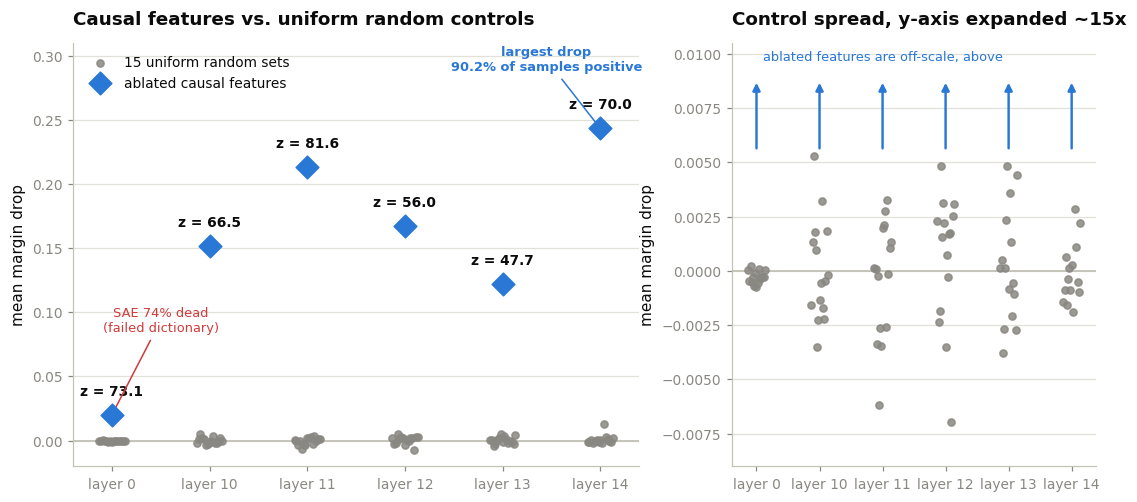

layer   ablated   ctrl mean (sd)        z      %pos   flips c->w
   0    0.0200   -0.00028 (0.00028)    73.1   56.6%   0
  10    0.1514   +0.00004 (0.00228)    66.5   81.2%   3
  11    0.2131   -0.00039 (0.00261)    81.6   84.8%   4
  12    0.1670   +0.00059 (0.00297)    56.0   82.8%   3
  13    0.1220   +0.00023 (0.00255)    47.7   64.8%   3
  14    0.2433   +0.00076 (0.00347)    70.0   90.2%   2

largest drop:      layer 14 (0.2433)
largest z:         layer 11 (81.6)
most % positive:   layer 14 (90.2%)

layer 11 source: output/sae_experiments/sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json
layer 10 source: output/sae_experiments/sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json
layer 10 has a second run at results/ablation_v2/ablation_v2_results.summary.json:
   that file: 0.15097 (z = 56.2)   |   file used here: 0.15141 (z = 66.5)
   the technical summary reports the second of these; see the notes at the top.


In [3]:
ablation_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/results/ablation_v2_results.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/results/ablation_v2_results.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/results/ablation_v2_results.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/results/ablation_v2_results.summary.json",
}

layers = [0, 10, 11, 12, 13, 14]
binding, rand_sets, zs, fracpos, flips = [], [], [], [], []
for L in layers:
    d = json.load(open(ablation_paths[L]))
    sig = d["significance"]["mean_margin_drop"]
    binding.append(sig["binding"])
    zs.append(sig["z_score"])
    rand_sets.append([s["mean_margin_drop"] for s in d["random_set_summaries"]])
    fracpos.append(d["binding_results"]["field_summaries"]["margin_drop"]["frac_positive"])
    flips.append(d["binding_results_prediction_changes"]["correct_to_wrong"])

x = np.arange(len(layers))
jitter = np.linspace(-0.13, 0.13, 15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.55, 1]})

for i in range(len(layers)):
    ax1.scatter(x[i] + jitter, rand_sets[i], s=22, color=MUTED, alpha=0.85, zorder=3,
                label="15 uniform random sets" if i == 0 else None)
ax1.scatter(x, binding, s=110, marker="D", color=BLUE, zorder=4, label="ablated causal features")
for i in range(len(layers)):
    ax1.annotate("z = %.1f" % zs[i], xy=(x[i], binding[i]), xytext=(0, 13),
                 textcoords="offset points", ha="center", fontsize=9,
                 color=INK, fontweight="bold")
ax1.axhline(0, color=BASELINE, lw=1.2, zorder=1)
ax1.set_xticks(x)
ax1.set_xticklabels(["layer %d" % L for L in layers])
ax1.set_ylabel("mean margin drop")
ax1.set_ylim(-0.02, 0.31)
ax1.set_title("Causal features vs. uniform random controls", loc="left", pad=12)
ax1.legend(loc="upper left")
tidy(ax1)
ax1.annotate("SAE 74% dead\n(failed dictionary)", xy=(0, binding[0]), xytext=(0.5, 0.085),
             color=CRIT, fontsize=8.5, ha="center",
             arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))

top = int(np.argmax(binding))
ax1.annotate("largest drop\n%.1f%% of samples positive" % (fracpos[top] * 100),
             xy=(x[top], binding[top]), xytext=(x[top] - 0.55, binding[top] + 0.045),
             color=BLUE, fontsize=8.5, ha="center", fontweight="bold",
             arrowprops=dict(arrowstyle="-", color=BLUE, lw=1))

for i in range(len(layers)):
    ax2.scatter(x[i] + jitter, rand_sets[i], s=22, color=MUTED, alpha=0.85, zorder=3)
    ax2.annotate("", xy=(x[i], 0.0088), xytext=(x[i], 0.0055),
                 arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=1.6))
ax2.axhline(0, color=BASELINE, lw=1.2, zorder=1)
ax2.set_xticks(x)
ax2.set_xticklabels(["layer %d" % L for L in layers])
ax2.set_ylim(-0.009, 0.0105)
ax2.set_ylabel("mean margin drop")
ax2.set_title("Control spread, y-axis expanded ~15x", loc="left", pad=12)
ax2.text(2, 0.0097, "ablated features are off-scale, above", color=BLUE, fontsize=8.5, ha="center")
tidy(ax2)

fig.savefig(FIGDIR / "fig2_ablation_vs_controls.png")
plt.show()

print("layer   ablated   ctrl mean (sd)        z      %pos   flips c->w")
for i, L in enumerate(layers):
    print("  %2d    %.4f   %+.5f (%.5f)   %5.1f   %.1f%%   %d"
          % (L, binding[i], np.mean(rand_sets[i]), np.std(rand_sets[i], ddof=0),
             zs[i], fracpos[i] * 100, flips[i]))
print()
print("largest drop:      layer %d (%.4f)" % (layers[int(np.argmax(binding))], max(binding)))
print("largest z:         layer %d (%.1f)" % (layers[int(np.argmax(zs))], max(zs)))
print("most %% positive:   layer %d (%.1f%%)" % (layers[int(np.argmax(fracpos))], max(fracpos) * 100))
print()
print("layer 11 source:", ablation_paths[11].relative_to(REPO))
print("layer 10 source:", ablation_paths[10].relative_to(REPO))

nested10 = SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_v2/ablation_v2_results.summary.json"
alt = json.load(open(nested10))["significance"]["mean_margin_drop"]
print("layer 10 has a second run at results/ablation_v2/ablation_v2_results.summary.json:")
print("   that file: %.5f (z = %.1f)   |   file used here: %.5f (z = %.1f)"
      % (alt["binding"], alt["z_score"], binding[1], zs[1]))
print("   the technical summary reports the second of these; see the notes at the top.")

---

### Figure 3 — Ablation as a fraction of the knockout ceiling

Knockout removes the whole `Image->Question` flow at a layer, so its margin drop is the
natural ceiling for what feature ablation at the same layer can recover; across the mid-network
cluster 200 features capture 50-68% of it. Caveat: **layer 13 is excluded rather than
plotted** — its knockout drop is negative (-0.0483), so the ratio is undefined, and layer 0's
4.4% reflects its failed SAE (74% dead features) rather than a property of the layer.

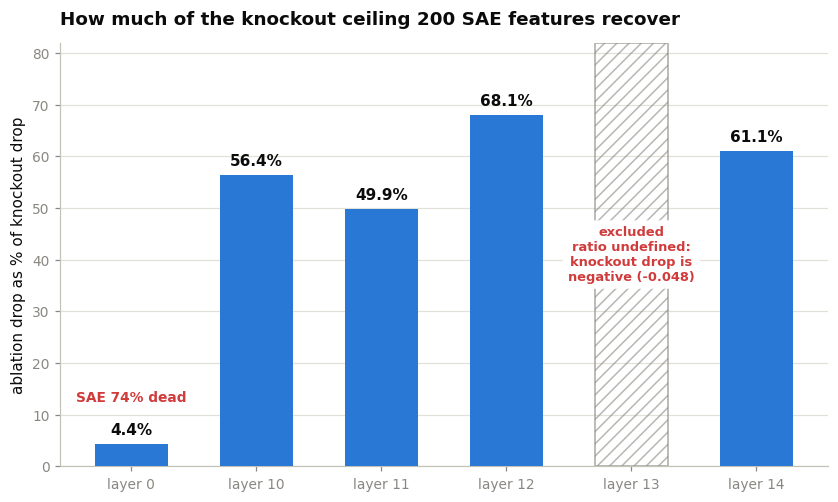

layer   ablation   knockout   % of ceiling
   0     0.0200     0.4575      4.4%
  10     0.1514     0.2683      56.4%
  11     0.2131     0.4273      49.9%
  12     0.1670     0.2452      68.1%
  13     0.1220    -0.0483      undefined (knockout drop is negative)
  14     0.2433     0.3983      61.1%


In [4]:
ko = json.load(open(SAE / "exp_default/knockout/knockout_summary.json"))
knockout_q = {r["layer"]: r["mean_margin_drop"] for r in ko if r["flow"] == "Image->Question"}

ablation_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/results/ablation_v2_results.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/results/ablation_v2_results.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/results/ablation_v2_results.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/results/ablation_v2_results.summary.json",
}

ablated = {L: json.load(open(p))["significance"]["mean_margin_drop"]["binding"]
           for L, p in ablation_paths.items()}

# Layer 13's knockout drop is negative, so the ratio is undefined and it is marked, not plotted.
layers = [0, 10, 11, 12, 13, 14]
excluded = 13

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(layers))

TOP = 82

for xi, L in zip(x, layers):
    if L == excluded:
        # Full-height hatch, so the excluded layer cannot be misread as a bar of some value.
        ax.bar(xi, TOP, width=0.58, facecolor="none", edgecolor=MUTED, hatch="///", lw=1.2,
               alpha=0.6, zorder=2)
        ax.text(xi, TOP / 2, "excluded\nratio undefined:\nknockout drop is\nnegative (-0.048)",
                ha="center", va="center", fontsize=8.5, color=CRIT, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor="none"))
        continue
    p = 100 * ablated[L] / knockout_q[L]
    ax.bar(xi, p, width=0.58, color=BLUE, zorder=3)
    ax.text(xi, p + 1.8, "%.1f%%" % p, ha="center", fontsize=10, fontweight="bold", color=INK)

ax.set_xticks(x)
ax.set_xticklabels(["layer %d" % L for L in layers])
ax.set_ylabel("ablation drop as % of knockout drop")
ax.set_ylim(0, TOP)
ax.set_title("How much of the knockout ceiling 200 SAE features recover", loc="left", pad=12)
tidy(ax)
ax.text(0, 100 * ablated[0] / knockout_q[0] + 8.2, "SAE 74% dead",
        color=CRIT, fontsize=9, ha="center", fontweight="bold")

fig.savefig(FIGDIR / "fig3_fraction_of_ceiling.png")
plt.show()

print("layer   ablation   knockout   % of ceiling")
for L in layers:
    if L == excluded:
        print("  %2d     %.4f    %+.4f      undefined (knockout drop is negative)"
              % (L, ablated[L], knockout_q[L]))
    else:
        print("  %2d     %.4f     %.4f      %.1f%%"
              % (L, ablated[L], knockout_q[L], 100 * ablated[L] / knockout_q[L]))

---

### Figure 4 — Why the v1 feature-selection metric produced 18 null results

v1 scored features by the ratio of mean activation on correct vs. incorrect samples, a metric
maximised by features that barely activate; its top-500 sit ~70x below the top-500 that v2's
gradient attribution selects, which is why ablating them changed nothing.
Caveat: these are **different dictionaries, not a matched ablation** — v1 (`sae_q_layer11`)
was trained on GQA at the residual site with `attribute` positions and only 14,914 of its
32,768 features ever activated, against CLEVR-Lite / `attn_out` / `question` positions for
v2, so the figure is evidence about the *selection metric*, not about a like-for-like
comparison of the two feature sets.

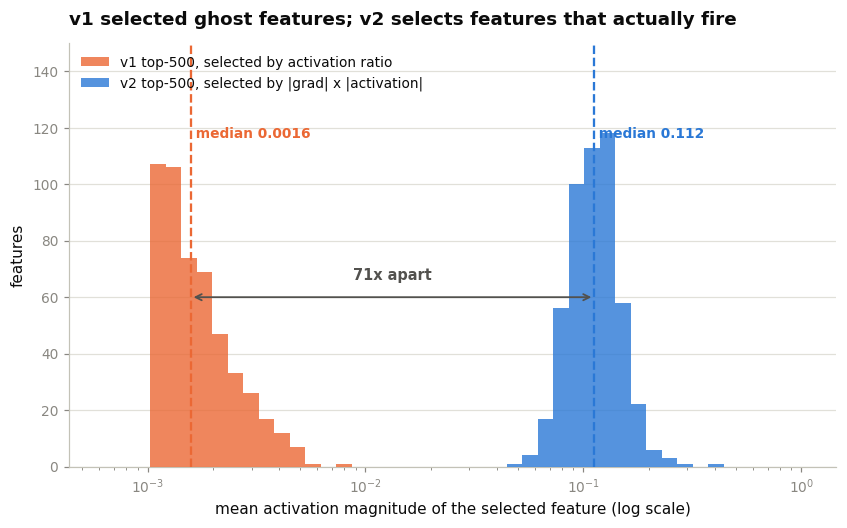

v1 top-500 activation (correct_mean): median 0.00157   min 0.00105   max 0.00847
v2 top-500 activation:                median 0.11231   min 0.04968   max 0.39876
ratio of medians: 71x

v2 mean activation across all 32768 features: median 6.07e-08  (top-500 mean 0.1168)

top-200 overlap between v1 and v2: 2 features [18443, 20629]
top-500 overlap: 9

NOTE: LLM_TECHNICAL_SUMMARY.md states 'zero overlap' between the v1 and v2 top-200 sets.
      The committed catalogs give 2. The value printed above is the computed one.
      Both dictionaries are 32768 wide; v1's 14914 is n_features_scored, not its width,
      and the two were trained on different data, sites and positions -- so feature ids
      are not comparable across them and the overlap is near-meaningless either way.


In [5]:
v1 = json.load(open(SAE / "sae_q_layer11/feature_stats.summary.json"))
v2 = json.load(open(SAE / "sae_clevr_lite_layer11_attn_out_question_causal/causal_feature_stats.summary.json"))

v1_act = [f["correct_mean"] for f in v1["top_features"]]
v2_act = [f["activation_mean"] for f in v2["top_features"]]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.logspace(-3.2, 0, 46)

ax.hist(v1_act, bins=bins, color=ORANGE, alpha=0.8, zorder=3,
        label="v1 top-500, selected by activation ratio")
ax.hist(v2_act, bins=bins, color=BLUE, alpha=0.8, zorder=3,
        label="v2 top-500, selected by |grad| x |activation|")

ax.axvline(np.median(v1_act), color=ORANGE, lw=1.5, ls="--", zorder=4)
ax.axvline(np.median(v2_act), color=BLUE, lw=1.5, ls="--", zorder=4)
ax.text(np.median(v1_act), 118, " median %.4f" % np.median(v1_act), color=ORANGE,
        fontsize=9, fontweight="bold", va="center")
ax.text(np.median(v2_act), 118, " median %.3f" % np.median(v2_act), color=BLUE,
        fontsize=9, fontweight="bold", va="center")
ax.annotate("", xy=(np.median(v2_act), 60), xytext=(np.median(v1_act), 60),
            arrowprops=dict(arrowstyle="<->", color=SECOND, lw=1.2))
ax.text(np.sqrt(np.median(v1_act) * np.median(v2_act)), 66,
        "%.0fx apart" % (np.median(v2_act) / np.median(v1_act)),
        color=SECOND, fontsize=9.5, fontweight="bold", ha="center")

ax.set_xscale("log")
ax.set_ylim(0, 150)
ax.set_xlabel("mean activation magnitude of the selected feature (log scale)")
ax.set_ylabel("features")
ax.set_title("v1 selected ghost features; v2 selects features that actually fire", loc="left", pad=12)
ax.legend(loc="upper left")
tidy(ax)

fig.savefig(FIGDIR / "fig4_v1_ghost_features.png")
plt.show()

print("v1 top-500 activation (correct_mean): median %.5f   min %.5f   max %.5f"
      % (np.median(v1_act), min(v1_act), max(v1_act)))
print("v2 top-500 activation:                median %.5f   min %.5f   max %.5f"
      % (np.median(v2_act), min(v2_act), max(v2_act)))
print("ratio of medians: %.0fx" % (np.median(v2_act) / np.median(v1_act)))
print()
print("v2 mean activation across all %d features: median %.3g  (top-500 mean %.4f)"
      % (v2["n_features_total"], v2["activation_mean_all"]["p50"], v2["activation_mean_top_k"]["mean"]))
print()

v1_top200 = set(f["feature"] for f in v1["top_features"][:200])
v2_top200 = set(f["feature"] for f in v2["top_features"][:200])
overlap = sorted(v1_top200 & v2_top200)
print("top-200 overlap between v1 and v2:", len(overlap), "features", overlap)
print("top-500 overlap:", len(set(f["feature"] for f in v1["top_features"]) &
                              set(f["feature"] for f in v2["top_features"])))
print()
print("NOTE: LLM_TECHNICAL_SUMMARY.md states 'zero overlap' between the v1 and v2 top-200 sets.")
print("      The committed catalogs give 2. The value printed above is the computed one.")
print("      Both dictionaries are 32768 wide; v1's 14914 is n_features_scored, not its width,")
print("      and the two were trained on different data, sites and positions -- so feature ids")
print("      are not comparable across them and the overlap is near-meaningless either way.")

---

### Figure 5 — Causal score is concentrated in a few hundred features at every working layer

Cumulative causal-score mass rises steeply with rank across the whole mid-network cluster —
at layer 14 the 200 features that were actually ablated carry 43.7% of the total score, and
500 carry 76.2% of 32,768 — which is the quantitative form of the claim that the image-to-text
flow is mediated by a sparse set of features. The five working layers are nearly
indistinguishable (top-200 share 36-46%), so the concentration is a property of the method
rather than of any one layer. Two caveats: the committed summaries retain only the top 500, so
every curve stops at rank 500; and **layer 0's much steeper curve is an artifact of its failed
dictionary**, not real concentration — with 74% of features dead, only 4,485 are nonzero, so
the same score mass is spread over a sixth as many candidates.

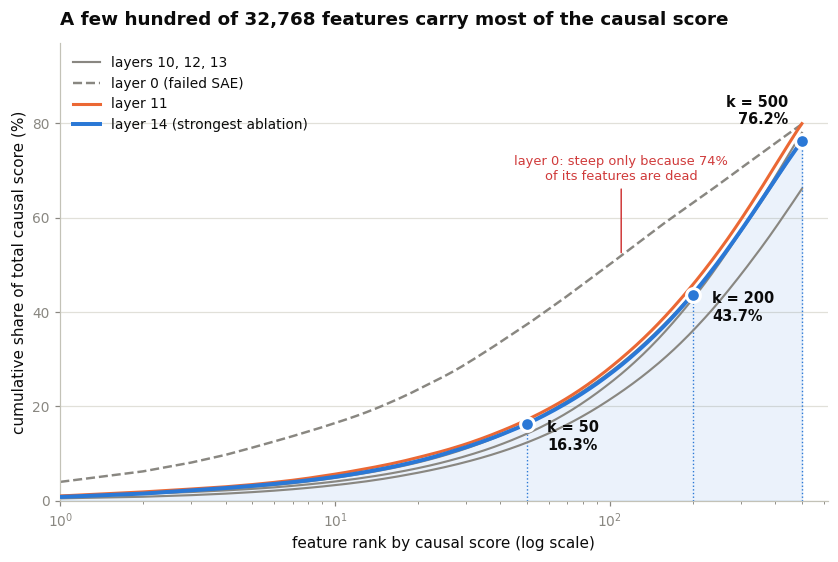

layer   top-50   top-200   top-500   nonzero features   top-500 mean activation
   0     37.4%    63.1%     79.9%               4485   0.0034
  10     14.2%    42.7%     78.0%              28264   0.0891
  11     17.2%    45.7%     79.9%              27810   0.1168
  12     12.3%    36.0%     66.1%              27298   0.1069
  13     16.4%    43.9%     76.5%              26649   0.1172
  14     16.3%    43.7%     76.2%              27918   0.1565

cross-check of the plotted curve against the stored fields:
  layer 11 top- 50  computed 0.1717   summary field 0.1717
  layer 11 top-200  computed 0.4573   summary field 0.4573
  layer 11 top-500  computed 0.7994   summary field 0.7994
  layer 14 top- 50  computed 0.1632   summary field 0.1632
  layer 14 top-200  computed 0.4369   summary field 0.4369
  layer 14 top-500  computed 0.7623   summary field 0.7623


In [6]:
# Layer 10 nests its causal stats one level deeper than the others.
stats_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/causal_feature_stats.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_v2/causal_feature_stats.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/causal_feature_stats.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/causal_feature_stats.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/causal_feature_stats.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/causal_feature_stats.summary.json",
}

stats = {L: json.load(open(p)) for L, p in stats_paths.items()}
curves = {L: 100 * np.cumsum([f["causal_score"] for f in d["top_features"]]) / d["score_mass_total"]
          for L, d in stats.items()}
rank = np.arange(1, 501)

fig, ax = plt.subplots(figsize=(9, 5.4))

for L in (10, 12, 13):
    ax.plot(rank, curves[L], color=MUTED, lw=1.4, zorder=2,
            label="layers 10, 12, 13" if L == 10 else None)
ax.plot(rank, curves[0], color=MUTED, lw=1.6, ls="--", zorder=2, label="layer 0 (failed SAE)")
ax.plot(rank, curves[11], color=ORANGE, lw=2, zorder=3, label="layer 11")
ax.plot(rank, curves[14], color=BLUE, lw=2.6, zorder=4, label="layer 14 (strongest ablation)")
ax.fill_between(rank, 0, curves[14], color=BLUE, alpha=0.09, zorder=1)

for k, offset in [(50, (13, -17)), (200, (13, -17)), (500, (-9, 11))]:
    y = curves[14][k - 1]
    ax.plot(k, y, marker="o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=6)
    ax.annotate("k = %d\n%.1f%%" % (k, y), xy=(k, y), xytext=offset,
                textcoords="offset points", fontsize=9.5, fontweight="bold", color=INK,
                ha="right" if k == 500 else "left")
    ax.plot([k, k], [0, y], color=BLUE, lw=0.9, ls=":", zorder=1)

ax.annotate("layer 0: steep only because 74%\nof its features are dead", xy=(110, curves[0][109]),
            xytext=(110, 68), color=CRIT, fontsize=8.5, ha="center",
            arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))

ax.set_xscale("log")
ax.set_xlim(1, 620)
ax.set_ylim(0, 97)
ax.set_xlabel("feature rank by causal score (log scale)")
ax.set_ylabel("cumulative share of total causal score (%)")
ax.set_title("A few hundred of 32,768 features carry most of the causal score", loc="left", pad=12)
ax.legend(loc="upper left")
tidy(ax)

fig.savefig(FIGDIR / "fig5_score_concentration.png")
plt.show()

print("layer   top-50   top-200   top-500   nonzero features   top-500 mean activation")
for L in (0, 10, 11, 12, 13, 14):
    d = stats[L]
    print("  %2d     %.1f%%    %.1f%%     %.1f%%   %16d   %.4f"
          % (L, 100 * d["score_mass_frac_top50"], 100 * d["score_mass_frac_top200"],
             100 * d["score_mass_frac_top500"], d["n_nonzero"],
             d["activation_mean_top_k"]["mean"]))
print()
print("cross-check of the plotted curve against the stored fields:")
for L in (11, 14):
    for k in (50, 200, 500):
        print("  layer %2d top-%3d  computed %.4f   summary field %.4f"
              % (L, k, curves[L][k - 1] / 100, stats[L]["score_mass_frac_top%d" % k]))